In [1]:
!pip -q install fasttext-wheel

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 2.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import re
import gzip
import shutil
import urllib.request
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.linear_model import LogisticRegression

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import fasttext

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

Device: cpu


In [3]:
LANGUAGES = {
    "asm_Beng": "Assamese",
    "ben_Beng": "Bengali",
    "brx_Deva": "Bodo",
    "doi_Deva": "Dogri",
    "gom_Deva": "Konkani",
    "guj_Gujr": "Gujarati",
    "hin_Deva": "Hindi",
    "kan_Knda": "Kannada",
    "kas_Arab": "Kashmiri",
    "mai_Deva": "Maithili",
    "mal_Mlym": "Malayalam",
    "mar_Deva": "Marathi",
    "mni_Mtei": "Manipuri",
    "npi_Deva": "Nepali",
    "ory_Orya": "Odia",
    "pan_Guru": "Punjabi",
    "san_Deva": "Sanskrit",
    "snd_Deva": "Sindhi",
    "tam_Taml": "Tamil",
    "tel_Telu": "Telugu",
    "urd_Arab": "Urdu",
    "khasi": "Khasi",
    "santhali": "Santali"
}

print("Number of languages:", len(LANGUAGES))

Number of languages: 23


In [4]:
from google.colab import files

uploaded = files.upload()

Saving indic_language_dataset.csv to indic_language_dataset.csv


In [5]:
import pandas as pd

df = pd.read_csv("indic_language_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())

df.head()

Dataset shape: (23000, 2)

Columns: ['text', 'label']


,text,label
0,ঘটনাৰ বিৱৰণি মতে বোকাকাতৰ কৈলাখাতত নিয়মিতভাৱে ...,asm_Beng
1,বোকাখাতৰ কৈলাখাতত নিয়মিতভাৱে বহা এই জুৱাৰ থলীত...,asm_Beng
2,ৰাণু মণ্ডলৰ সুৱদী কন্ঠত মুগ্ধ হৈ ভাইজান ছলমানে...,asm_Beng
3,"বহুতে ইয়াকো কৈছে যে, ছলমানৰ আহিবলগীয়া ছবিৰ বাব...",asm_Beng
4,কিন্তু আঁচল কথাতো হল ছচিয়েল মিডিয়াত প্ৰচাৰিত এ...,asm_Beng


In [6]:
print(df["label"].value_counts())

print("\nTotal samples:", len(df))
print("Number of languages:", df["label"].nunique())

label
asm_Beng    1000
ben_Beng    1000
brx_Deva    1000
doi_Deva    1000
gom_Deva    1000
guj_Gujr    1000
hin_Deva    1000
kan_Knda    1000
kas_Arab    1000
mai_Deva    1000
mal_Mlym    1000
mar_Deva    1000
mni_Mtei    1000
npi_Deva    1000
ory_Orya    1000
pan_Guru    1000
san_Deva    1000
snd_Deva    1000
tam_Taml    1000
tel_Telu    1000
urd_Arab    1000
khasi       1000
santhali    1000
Name: count, dtype: int64

Total samples: 23000
Number of languages: 23


In [7]:
import numpy as np

np.random.seed(42)

train_texts = []
val_texts = []
test_texts = []

train_labels = []
val_labels = []
test_labels = []

for lang in LANGUAGES:

    lang_df = df[df["label"] == lang].copy()

    # Shuffle samples of this language
    lang_df = lang_df.sample(
        frac=1,
        random_state=42
    ).reset_index(drop=True)

    train_part = lang_df.iloc[:800]
    val_part = lang_df.iloc[800:900]
    test_part = lang_df.iloc[900:1000]

    train_texts.extend(
        train_part["text"].tolist()
    )
    train_labels.extend(
        train_part["label"].tolist()
    )

    val_texts.extend(
        val_part["text"].tolist()
    )
    val_labels.extend(
        val_part["label"].tolist()
    )

    test_texts.extend(
        test_part["text"].tolist()
    )
    test_labels.extend(
        test_part["label"].tolist()
    )


print("Train samples:", len(train_texts))
print("Validation samples:", len(val_texts))
print("Test samples:", len(test_texts))

Train samples: 18400
Validation samples: 2300
Test samples: 2300


In [8]:
label_names = list(LANGUAGES.keys())

label_to_id = {
    label: i
    for i, label in enumerate(label_names)
}

id_to_label = {
    i: label
    for label, i in label_to_id.items()
}

y_train = np.array([
    label_to_id[label]
    for label in train_labels
])

y_val = np.array([
    label_to_id[label]
    for label in val_labels
])

y_test = np.array([
    label_to_id[label]
    for label in test_labels
])

N_CLASSES = len(label_names)

print("Number of classes:", N_CLASSES)
print("\nLabel mapping:")

for label, idx in label_to_id.items():
    print(idx, "->", label, "->", LANGUAGES[label])

Number of classes: 23

Label mapping:
0 -> asm_Beng -> Assamese
1 -> ben_Beng -> Bengali
2 -> brx_Deva -> Bodo
3 -> doi_Deva -> Dogri
4 -> gom_Deva -> Konkani
5 -> guj_Gujr -> Gujarati
6 -> hin_Deva -> Hindi
7 -> kan_Knda -> Kannada
8 -> kas_Arab -> Kashmiri
9 -> mai_Deva -> Maithili
10 -> mal_Mlym -> Malayalam
11 -> mar_Deva -> Marathi
12 -> mni_Mtei -> Manipuri
13 -> npi_Deva -> Nepali
14 -> ory_Orya -> Odia
15 -> pan_Guru -> Punjabi
16 -> san_Deva -> Sanskrit
17 -> snd_Deva -> Sindhi
18 -> tam_Taml -> Tamil
19 -> tel_Telu -> Telugu
20 -> urd_Arab -> Urdu
21 -> khasi -> Khasi
22 -> santhali -> Santali


In [9]:
def macro_f1(y_true, y_pred, n_classes):

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    f1_scores = []

    for c in range(n_classes):

        tp = np.sum(
            (y_true == c) & (y_pred == c)
        )

        fp = np.sum(
            (y_true != c) & (y_pred == c)
        )

        fn = np.sum(
            (y_true == c) & (y_pred != c)
        )

        precision = tp / (tp + fp + 1e-8)

        recall = tp / (tp + fn + 1e-8)

        f1 = (
            2 * precision * recall /
            (precision + recall + 1e-8)
        )

        f1_scores.append(f1)

    return np.mean(f1_scores)

In [10]:
import re

def clean_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        " ",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


train_texts = [
    clean_text(text)
    for text in train_texts
]

val_texts = [
    clean_text(text)
    for text in val_texts
]

test_texts = [
    clean_text(text)
    for text in test_texts
]

print(train_texts[0])
print(train_labels[0])

সমান্তৰালকৈ, এই গীতটিৰ ভিডিঅ’ত অভিনয় কৰিছে নিতুপম দিহিঙিয়াই।
asm_Beng


In [12]:
FASTTEXT_CODES = {

    "asm_Beng": "as",
    "ben_Beng": "bn",
    "brx_Deva": "brx",
    "doi_Deva": "doi",
    "gom_Deva": "gom",

    "guj_Gujr": "gu",
    "hin_Deva": "hi",
    "kan_Knda": "kn",
    "kas_Arab": "ks",
    "mai_Deva": "mai",

    "mal_Mlym": "ml",
    "mar_Deva": "mr",
    "mni_Mtei": "mni",
    "npi_Deva": "ne",
    "ory_Orya": "or",

    "pan_Guru": "pa",
    "san_Deva": "sa",
    "snd_Deva": "sd",
    "tam_Taml": "ta",
    "tel_Telu": "te",

    "urd_Arab": "ur",
    "khasi": "kha",
    "santhali": "sat"
}

print("Mapped languages:", len(FASTTEXT_CODES))

Mapped languages: 23


In [13]:
def tokenize(text):
    return text.split()


all_words = set()

for text in train_texts:
    all_words.update(tokenize(text))

for text in val_texts:
    all_words.update(tokenize(text))

for text in test_texts:
    all_words.update(tokenize(text))


print("Unique words:", len(all_words))

Unique words: 142800


In [14]:
import os
import urllib.request
import zipfile

EMBEDDING_DIM = 300

WIKI_DIR = "/content/wiki_vectors"

os.makedirs(
    WIKI_DIR,
    exist_ok=True
)


def download_wiki_vectors(code):

    vec_path = os.path.join(
        WIKI_DIR,
        f"wiki.{code}.vec"
    )

    zip_path = os.path.join(
        WIKI_DIR,
        f"wiki.{code}.zip"
    )

    if os.path.exists(vec_path):
        return vec_path

    url = (
        "https://dl.fbaipublicfiles.com/"
        f"fasttext/vectors-wiki/"
        f"wiki.{code}.zip"
    )

    print(f"Downloading {code}...")

    try:

        urllib.request.urlretrieve(
            url,
            zip_path
        )

        print(f"Extracting {code}...")

        with zipfile.ZipFile(
            zip_path,
            "r"
        ) as z:

            z.extractall(WIKI_DIR)

        os.remove(zip_path)

        if os.path.exists(vec_path):
            return vec_path

    except Exception as e:

        print(
            f"Wiki vectors unavailable for {code}"
        )

        if os.path.exists(zip_path):
            os.remove(zip_path)

    return None

In [15]:
def load_needed_vectors(
    filepath,
    needed_words
):

    vectors = {}

    if filepath is None:
        return vectors

    with open(
        filepath,
        "r",
        encoding="utf-8",
        errors="ignore"
    ) as f:

        # Skip header
        f.readline()

        for line in f:

            parts = line.rstrip().split()

            if len(parts) != EMBEDDING_DIM + 1:
                continue

            word = parts[0]

            if word not in needed_words:
                continue

            try:

                vector = np.asarray(
                    parts[1:],
                    dtype=np.float32
                )

                vectors[word] = vector

            except:
                continue

    return vectors

In [16]:
word_vectors = {}

available_languages = []
missing_languages = []


for dataset_code, ft_code in FASTTEXT_CODES.items():

    print("\n" + "=" * 50)

    print(
        LANGUAGES[dataset_code],
        "->",
        ft_code
    )

    filepath = download_wiki_vectors(
        ft_code
    )

    if filepath is None:

        missing_languages.append(
            LANGUAGES[dataset_code]
        )

        continue


    vectors = load_needed_vectors(
        filepath,
        all_words
    )

    print(
        "Vectors found:",
        len(vectors)
    )


    for word, vector in vectors.items():

        if word not in word_vectors:

            word_vectors[word] = vector


    available_languages.append(
        LANGUAGES[dataset_code]
    )


    # Delete the huge .vec file
    # after extracting needed vectors

    try:
        os.remove(filepath)
    except:
        pass


print("\nDONE")

print(
    "\nAvailable languages:",
    available_languages
)

print(
    "\nMissing languages:",
    missing_languages
)

print(
    "\nTotal word vectors:",
    len(word_vectors)
)


Assamese -> as
Extracting as...
Vectors found: 7656

Bengali -> bn
Extracting bn...
Vectors found: 8048

Bodo -> brx
Wiki vectors unavailable for brx

Dogri -> doi
Wiki vectors unavailable for doi

Konkani -> gom
Extracting gom...
Vectors found: 4976

Gujarati -> gu
Extracting gu...
Vectors found: 6611

Hindi -> hi
Extracting hi...
Vectors found: 12962

Kannada -> kn
Extracting kn...
Vectors found: 6875

Kashmiri -> ks
Extracting ks...
Vectors found: 719

Maithili -> mai
Extracting mai...
Vectors found: 4214

Malayalam -> ml
Extracting ml...
Vectors found: 5699

Marathi -> mr
Extracting mr...
Vectors found: 11913

Manipuri -> mni
Wiki vectors unavailable for mni

Nepali -> ne
Extracting ne...
Vectors found: 10593

Odia -> or
Extracting or...
Vectors found: 3541

Punjabi -> pa
Extracting pa...
Vectors found: 6213

Sanskrit -> sa
Extracting sa...
Vectors found: 5200

Sindhi -> sd
Extracting sd...
Vectors found: 7035

Tamil -> ta
Extracting ta...
Vectors found: 6936

Telugu -> te
Extract

In [17]:
def sentence_vector(text):

    words = tokenize(text)

    vectors = [
        word_vectors[word]
        for word in words
        if word in word_vectors
    ]

    if len(vectors) == 0:
        return np.zeros(
            EMBEDDING_DIM,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    ).astype(np.float32)

In [18]:
print("Creating train vectors...")

X_train = np.vstack([
    sentence_vector(text)
    for text in train_texts
])

print("Creating validation vectors...")

X_val = np.vstack([
    sentence_vector(text)
    for text in val_texts
])

print("Creating test vectors...")

X_test = np.vstack([
    sentence_vector(text)
    for text in test_texts
])

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Creating train vectors...
Creating validation vectors...
Creating test vectors...
X_train: (18400, 300)
X_val: (2300, 300)
X_test: (2300, 300)


In [19]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

lr_f1 = macro_f1(
    y_test,
    lr_pred,
    N_CLASSES
)

print(
    "Logistic Regression Macro-F1:",
    round(lr_f1, 4)
)

Logistic Regression Macro-F1: 0.849


In [20]:
import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [21]:
class VectorDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

In [22]:
train_vector_dataset = VectorDataset(
    X_train,
    y_train
)

val_vector_dataset = VectorDataset(
    X_val,
    y_val
)

test_vector_dataset = VectorDataset(
    X_test,
    y_test
)


train_vector_loader = DataLoader(
    train_vector_dataset,
    batch_size=64,
    shuffle=True
)

val_vector_loader = DataLoader(
    val_vector_dataset,
    batch_size=64
)

test_vector_loader = DataLoader(
    test_vector_dataset,
    batch_size=64
)

In [23]:
def predict_torch_model(
    model,
    loader
):

    model.eval()

    predictions = []

    with torch.no_grad():

        for X_batch, _ in loader:

            X_batch = X_batch.to(
                device
            )

            outputs = model(
                X_batch
            )

            pred = torch.argmax(
                outputs,
                dim=1
            )

            predictions.extend(
                pred.cpu().numpy()
            )

    return np.array(
        predictions
    )

In [24]:
def train_torch_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001
):

    model = model.to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    best_val_f1 = -1
    best_state = None

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        avg_loss = (
            total_loss /
            len(train_loader)
        )

        val_pred = predict_torch_model(
            model,
            val_loader
        )

        val_true = np.concatenate([
            y.numpy()
            for _, y in val_loader
        ])

        val_f1 = macro_f1(
            val_true,
            val_pred,
            N_CLASSES
        )

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Loss: {avg_loss:.4f} | "
            f"Val Macro-F1: {val_f1:.4f}"
        )

        if val_f1 > best_val_f1:

            best_val_f1 = val_f1

            best_state = {
                k: v.cpu().clone()
                for k, v
                in model.state_dict().items()
            }

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return model

In [25]:
class MLPClassifier(nn.Module):

    def __init__(
        self,
        input_dim,
        num_classes,
        n_hidden=0,
        hidden_dim=256
    ):

        super().__init__()

        layers = []

        if n_hidden == 0:

            layers.append(
                nn.Linear(
                    input_dim,
                    num_classes
                )
            )

        else:

            layers.extend([
                nn.Linear(
                    input_dim,
                    hidden_dim
                ),
                nn.ReLU(),
                nn.Dropout(0.3)
            ])

            for _ in range(
                n_hidden - 1
            ):

                layers.extend([
                    nn.Linear(
                        hidden_dim,
                        hidden_dim
                    ),
                    nn.ReLU(),
                    nn.Dropout(0.3)
                ])

            layers.append(
                nn.Linear(
                    hidden_dim,
                    num_classes
                )
            )

        self.network = nn.Sequential(
            *layers
        )

    def forward(self, x):

        return self.network(x)

In [26]:
mlp0 = MLPClassifier(
    input_dim=EMBEDDING_DIM,
    num_classes=N_CLASSES,
    n_hidden=0
)

mlp0 = train_torch_model(
    mlp0,
    train_vector_loader,
    val_vector_loader,
    epochs=10
)

mlp0_pred = predict_torch_model(
    mlp0,
    test_vector_loader
)

mlp0_f1 = macro_f1(
    y_test,
    mlp0_pred,
    N_CLASSES
)

print(
    "\nMLP 0 Hidden Layers Macro-F1:",
    round(mlp0_f1, 4)
)

Epoch 1/10 | Loss: 1.7769 | Val Macro-F1: 0.7762
Epoch 2/10 | Loss: 0.9324 | Val Macro-F1: 0.7968
Epoch 3/10 | Loss: 0.7647 | Val Macro-F1: 0.8021
Epoch 4/10 | Loss: 0.6853 | Val Macro-F1: 0.8185
Epoch 5/10 | Loss: 0.6350 | Val Macro-F1: 0.8233
Epoch 6/10 | Loss: 0.5970 | Val Macro-F1: 0.8251
Epoch 7/10 | Loss: 0.5670 | Val Macro-F1: 0.8276
Epoch 8/10 | Loss: 0.5445 | Val Macro-F1: 0.8290
Epoch 9/10 | Loss: 0.5246 | Val Macro-F1: 0.8283
Epoch 10/10 | Loss: 0.5092 | Val Macro-F1: 0.8297

MLP 0 Hidden Layers Macro-F1: 0.8434


In [27]:
mlp1 = MLPClassifier(
    input_dim=EMBEDDING_DIM,
    num_classes=N_CLASSES,
    n_hidden=1
)

mlp1 = train_torch_model(
    mlp1,
    train_vector_loader,
    val_vector_loader,
    epochs=10
)

mlp1_pred = predict_torch_model(
    mlp1,
    test_vector_loader
)

mlp1_f1 = macro_f1(
    y_test,
    mlp1_pred,
    N_CLASSES
)

print(
    "\nMLP 1 Hidden Layer Macro-F1:",
    round(mlp1_f1, 4)
)

Epoch 1/10 | Loss: 1.0678 | Val Macro-F1: 0.8077
Epoch 2/10 | Loss: 0.5145 | Val Macro-F1: 0.8311
Epoch 3/10 | Loss: 0.4612 | Val Macro-F1: 0.8414
Epoch 4/10 | Loss: 0.4307 | Val Macro-F1: 0.8468
Epoch 5/10 | Loss: 0.4092 | Val Macro-F1: 0.8486
Epoch 6/10 | Loss: 0.3925 | Val Macro-F1: 0.8580
Epoch 7/10 | Loss: 0.3812 | Val Macro-F1: 0.8516
Epoch 8/10 | Loss: 0.3662 | Val Macro-F1: 0.8493
Epoch 9/10 | Loss: 0.3572 | Val Macro-F1: 0.8412
Epoch 10/10 | Loss: 0.3469 | Val Macro-F1: 0.8503

MLP 1 Hidden Layer Macro-F1: 0.848


In [28]:
mlp2 = MLPClassifier(
    input_dim=EMBEDDING_DIM,
    num_classes=N_CLASSES,
    n_hidden=2
)

mlp2 = train_torch_model(
    mlp2,
    train_vector_loader,
    val_vector_loader,
    epochs=10
)

mlp2_pred = predict_torch_model(
    mlp2,
    test_vector_loader
)

mlp2_f1 = macro_f1(
    y_test,
    mlp2_pred,
    N_CLASSES
)

print(
    "\nMLP 2 Hidden Layers Macro-F1:",
    round(mlp2_f1, 4)
)

Epoch 1/10 | Loss: 0.9723 | Val Macro-F1: 0.8050
Epoch 2/10 | Loss: 0.5039 | Val Macro-F1: 0.8276
Epoch 3/10 | Loss: 0.4562 | Val Macro-F1: 0.8281
Epoch 4/10 | Loss: 0.4233 | Val Macro-F1: 0.8488
Epoch 5/10 | Loss: 0.4027 | Val Macro-F1: 0.8456
Epoch 6/10 | Loss: 0.3889 | Val Macro-F1: 0.8499
Epoch 7/10 | Loss: 0.3725 | Val Macro-F1: 0.8440
Epoch 8/10 | Loss: 0.3589 | Val Macro-F1: 0.8508
Epoch 9/10 | Loss: 0.3501 | Val Macro-F1: 0.8528
Epoch 10/10 | Loss: 0.3401 | Val Macro-F1: 0.8508

MLP 2 Hidden Layers Macro-F1: 0.848


In [29]:
from collections import Counter

word_counts = Counter()

for text in train_texts:
    word_counts.update(tokenize(text))

word_to_idx = {
    "<PAD>": 0,
    "<UNK>": 1
}

for word in word_counts:
    word_to_idx[word] = len(word_to_idx)

VOCAB_SIZE = len(word_to_idx)

print("Vocabulary size:", VOCAB_SIZE)

Vocabulary size: 120882


In [30]:
embedding_matrix = np.random.normal(
    0,
    0.05,
    (VOCAB_SIZE, EMBEDDING_DIM)
).astype(np.float32)

# Padding vector
embedding_matrix[0] = np.zeros(
    EMBEDDING_DIM,
    dtype=np.float32
)

matched_words = 0

for word, idx in word_to_idx.items():

    if word in word_vectors:

        embedding_matrix[idx] = word_vectors[word]
        matched_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Words with Wiki FastText vectors:", matched_words)

Embedding matrix shape: (120882, 300)
Words with Wiki FastText vectors: 58246


In [31]:
MAX_LENGTH = 50

def text_to_sequence(text):

    words = tokenize(text)

    sequence = [
        word_to_idx.get(
            word,
            word_to_idx["<UNK>"]
        )
        for word in words
    ]

    sequence = sequence[:MAX_LENGTH]

    if len(sequence) < MAX_LENGTH:

        sequence += [0] * (
            MAX_LENGTH - len(sequence)
        )

    return sequence

In [32]:
class SequenceDataset(Dataset):

    def __init__(self, texts, labels):

        self.X = np.array([
            text_to_sequence(text)
            for text in texts
        ])

        self.y = np.array(labels)

    def __len__(self):

        return len(self.y)

    def __getitem__(self, idx):

        return (
            torch.tensor(
                self.X[idx],
                dtype=torch.long
            ),
            torch.tensor(
                self.y[idx],
                dtype=torch.long
            )
        )

In [33]:
train_seq_dataset = SequenceDataset(
    train_texts,
    y_train
)

val_seq_dataset = SequenceDataset(
    val_texts,
    y_val
)

test_seq_dataset = SequenceDataset(
    test_texts,
    y_test
)


train_seq_loader = DataLoader(
    train_seq_dataset,
    batch_size=64,
    shuffle=True
)

val_seq_loader = DataLoader(
    val_seq_dataset,
    batch_size=64
)

test_seq_loader = DataLoader(
    test_seq_dataset,
    batch_size=64
)

print("Sequence loaders ready.")

Sequence loaders ready.


In [34]:
class LSTMClassifier(nn.Module):

    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        vocab_size, embedding_dim = (
            embedding_matrix.shape
        )

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, _ = self.lstm(embedded)

        # Find actual sentence lengths
        lengths = (x != 0).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        batch_indices = torch.arange(
            x.size(0),
            device=x.device
        )

        # Take output from final real word
        final_output = output[
            batch_indices,
            lengths - 1
        ]

        final_output = self.dropout(
            final_output
        )

        return self.fc(final_output)

In [35]:
lstm_model = LSTMClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_classes=N_CLASSES
)

lstm_model = train_torch_model(
    lstm_model,
    train_seq_loader,
    val_seq_loader,
    epochs=5,
    lr=0.001
)

Epoch 1/5 | Loss: 0.9536 | Val Macro-F1: 0.8362
Epoch 2/5 | Loss: 0.2544 | Val Macro-F1: 0.8683
Epoch 3/5 | Loss: 0.0958 | Val Macro-F1: 0.8648
Epoch 4/5 | Loss: 0.0332 | Val Macro-F1: 0.8772
Epoch 5/5 | Loss: 0.0149 | Val Macro-F1: 0.8663


In [36]:
lstm_pred = predict_torch_model(
    lstm_model,
    test_seq_loader
)

lstm_f1 = macro_f1(
    y_test,
    lstm_pred,
    N_CLASSES
)

print(
    "LSTM Macro-F1:",
    round(lstm_f1, 4)
)

LSTM Macro-F1: 0.8722


In [37]:
class GRUClassifier(nn.Module):

    def __init__(
        self,
        embedding_matrix,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        vocab_size, embedding_dim = (
            embedding_matrix.shape
        )

        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(
                embedding_matrix,
                dtype=torch.float32
            ),
            freeze=False,
            padding_idx=0
        )

        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(
            hidden_dim,
            num_classes
        )

    def forward(self, x):

        embedded = self.embedding(x)

        output, _ = self.gru(embedded)

        lengths = (x != 0).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        batch_indices = torch.arange(
            x.size(0),
            device=x.device
        )

        final_output = output[
            batch_indices,
            lengths - 1
        ]

        final_output = self.dropout(
            final_output
        )

        return self.fc(final_output)

In [38]:
gru_model = GRUClassifier(
    embedding_matrix=embedding_matrix,
    hidden_dim=128,
    num_classes=N_CLASSES
)

gru_model = train_torch_model(
    gru_model,
    train_seq_loader,
    val_seq_loader,
    epochs=5,
    lr=0.001
)

Epoch 1/5 | Loss: 0.8909 | Val Macro-F1: 0.8863
Epoch 2/5 | Loss: 0.1657 | Val Macro-F1: 0.9050
Epoch 3/5 | Loss: 0.0386 | Val Macro-F1: 0.8916
Epoch 4/5 | Loss: 0.0119 | Val Macro-F1: 0.8953
Epoch 5/5 | Loss: 0.0056 | Val Macro-F1: 0.8948


In [39]:
gru_pred = predict_torch_model(
    gru_model,
    test_seq_loader
)

gru_f1 = macro_f1(
    y_test,
    gru_pred,
    N_CLASSES
)

print(
    "GRU Macro-F1:",
    round(gru_f1, 4)
)

GRU Macro-F1: 0.9005


In [40]:
def create_fasttext_file(
    texts,
    labels,
    filename
):

    with open(
        filename,
        "w",
        encoding="utf-8"
    ) as f:

        for text, label in zip(
            texts,
            labels
        ):

            text = str(text).replace(
                "\n",
                " "
            )

            f.write(
                f"__label__{label} {text}\n"
            )


create_fasttext_file(
    train_texts,
    train_labels,
    "/content/fasttext_train.txt"
)

create_fasttext_file(
    val_texts,
    val_labels,
    "/content/fasttext_val.txt"
)

create_fasttext_file(
    test_texts,
    test_labels,
    "/content/fasttext_test.txt"
)

print("FastText files created.")

FastText files created.


In [41]:
with open(
    "/content/fasttext_train.txt",
    "r",
    encoding="utf-8"
) as f:

    for i in range(3):
        print(f.readline())

__label__asm_Beng সমান্তৰালকৈ, এই গীতটিৰ ভিডিঅ’ত অভিনয় কৰিছে নিতুপম দিহিঙিয়াই।

__label__asm_Beng ইয়াৰ পাছতো যদি মিমাংসা নিস্পত্তি নহয় তেন্তে প্ৰকৃতাৰ্থত তালাক হ'ব।

__label__asm_Beng মহিলাই তালাক দিব নোৱাৰে যদিও বিবাহ বিচছেদ কৰিব পাৰে।



In [42]:
fasttext_model = fasttext.train_supervised(
    input="/content/fasttext_train.txt",
    lr=0.5,
    epoch=20,
    wordNgrams=2,
    dim=100,
    loss="softmax",
    thread=4,
    verbose=2
)

In [53]:
def fasttext_predict(model, texts):

    predictions = []

    for text in texts:

        result = model.f.predict(
            str(text),
            1,          # top 1 prediction
            0.0,        # threshold
            "strict"    # unicode error handling
        )

        if len(result) == 0:
            print("No prediction for:", text[:50])
            predictions.append(0)
            continue

        # result looks like:
        # [(probability, '__label__hin_Deva')]

        predicted_label = result[0][1]

        predicted_label = predicted_label.replace(
            "__label__",
            ""
        )

        predictions.append(
            label_to_id[predicted_label]
        )

    return np.array(predictions)

In [54]:
fasttext_pred = fasttext_predict(
    fasttext_model,
    test_texts
)

fasttext_f1 = macro_f1(
    y_test,
    fasttext_pred,
    N_CLASSES
)

print(
    "FastText Classification Macro-F1:",
    round(fasttext_f1, 4)
)

No prediction for: <timestamp>2021-11-23T10:42:57Z</timestamp>
No prediction for: 93.905324090738,
No prediction for: 93.905324090738,
No prediction for: महानाम्नीर्म॑हामा॒नाः।
No prediction for: तिष्ठन्ना॑तप॒न्ति।
No prediction for: अ॒ग्निश्चा॑दि॒त्य॒श्च॑।
No prediction for: अ॒क्षरा᳚द्दीप्ति॒रुच्य॑ते।
No prediction for: दे॒वीर्भु॑वन॒सूव॑रीः।
No prediction for: रोदस्योन्त॑र्दे\-शे॒षु।
No prediction for: अपा᳚ण्य॒पाद॑केशा॒सः।
FastText Classification Macro-F1: 0.882


In [55]:
results = pd.DataFrame({

    "Classifier": [
        "Logistic Regression",
        "MLP - 0 Hidden Layers",
        "MLP - 1 Hidden Layer",
        "MLP - 2 Hidden Layers",
        "LSTM",
        "GRU",
        "FastText Classification"
    ],

    "Macro-F1": [
        lr_f1,
        mlp0_f1,
        mlp1_f1,
        mlp2_f1,
        lstm_f1,
        gru_f1,
        fasttext_f1
    ]
})

results = results.sort_values(
    by="Macro-F1",
    ascending=False
).reset_index(drop=True)

results

,Classifier,Macro-F1
0,GRU,0.900513
1,FastText Classification,0.881997
2,LSTM,0.872239
3,Logistic Regression,0.848982
4,MLP - 2 Hidden Layers,0.847979
5,MLP - 1 Hidden Layer,0.847960
6,MLP - 0 Hidden Layers,0.843423


In [56]:
print("=" * 65)
print("LANGUAGE IDENTIFICATION - LAB 6")
print("=" * 65)

for _, row in results.iterrows():

    print(
        f"{row['Classifier']:<30}"
        f"{row['Macro-F1']:.4f}"
    )

print("=" * 65)

print(
    "\nBest Classifier:",
    results.iloc[0]["Classifier"]
)

print(
    "Best Macro-F1:",
    round(
        results.iloc[0]["Macro-F1"],
        4
    )
)

LANGUAGE IDENTIFICATION - LAB 6
GRU                           0.9005
FastText Classification       0.8820
LSTM                          0.8722
Logistic Regression           0.8490
MLP - 2 Hidden Layers         0.8480
MLP - 1 Hidden Layer          0.8480
MLP - 0 Hidden Layers         0.8434

Best Classifier: GRU
Best Macro-F1: 0.9005


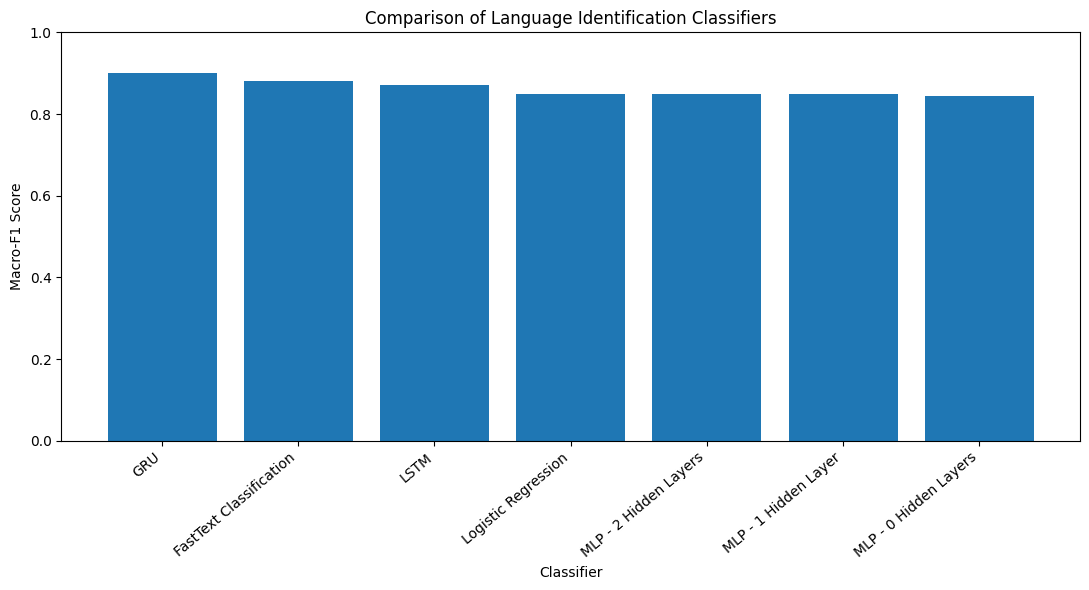

In [57]:
plt.figure(
    figsize=(11, 6)
)

plt.bar(
    results["Classifier"],
    results["Macro-F1"]
)

plt.xlabel(
    "Classifier"
)

plt.ylabel(
    "Macro-F1 Score"
)

plt.title(
    "Comparison of Language Identification Classifiers"
)

plt.xticks(
    rotation=40,
    ha="right"
)

plt.ylim(0, 1)

plt.tight_layout()

plt.show()